In [7]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os
import matplotlib.cm as cm
from io import StringIO
import sys
import nc_time_axis
import os

sys.path.append('C:/Users/madel/Code/GeoNorth')

from utils import *

In [8]:
site = "TVC"
ctsm_file = f"..\\CTSM_data\\run_1\\merged_files\\{site}_1995-2014.nc"
df = xr.open_dataset(ctsm_file, engine="netcdf4")

C:\Users\madel\AppData\Local\Temp\ipykernel_42272\2508831909.py:3: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset(ctsm_file, engine="netcdf4")


In [9]:
df

<xarray.Dataset> Size: 14MB
Dimensions:                        (time: 7300, hist_interval: 2, lndgrid: 1,
                                    levgrnd: 25, levlak: 10, levsoi: 20,
                                    cft: 64, glc_nec: 10, ltype: 9, natpft: 15,
                                    nvegwcs: 4, levdcmp: 1)
Coordinates:
  * time                           (time) object 58kB 1995-01-01 00:00:00 ......
  * levgrnd                        (levgrnd) float32 100B 0.01 0.04 ... 42.0
  * levlak                         (levlak) float32 40B 0.05 0.6 ... 34.33 44.78
  * levsoi                         (levsoi) float32 80B 0.01 0.04 ... 6.94 8.03
  * levdcmp                        (levdcmp) float32 4B 1.0
Dimensions without coordinates: hist_interval, lndgrid, cft, glc_nec, ltype,
                                natpft, nvegwcs
Data variables: (12/259)
    mcdate                         (time) int32 29kB ...
    mcsec                          (time) int32 29kB ...
    mdcur                          (time) int32 29kB ...
    mscur                          (time) int32 29kB ...
    nstep                          (time) int32 29kB ...
    time_bounds                    (time, hist_interval) object 117kB ...
    ...                             ...
    SOILLIQ                        (time, levsoi, lndgrid) float32 584kB ...
    PCT_LANDUNIT                   (time, ltype, lndgrid) float32 263kB ...
    PCT_NAT_PFT                    (time, natpft, lndgrid) float32 438kB ...
    VEGWP                          (time, nvegwcs, lndgrid) float32 117kB ...
    VEGWPLN                        (time, nvegwcs, lndgrid) float32 117kB ...
    VEGWPPD                        (time, nvegwcs, lndgrid) float32 117kB ...
Attributes: (12/100)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              Thu Mar 26 11:29:19 2026: ncrcat TV...
    source:                               Community Terrestrial Systems Model
    hostname:                             trillium
    ...                                   ...
    cft_tropical_corn:                    61
    cft_irrigated_tropical_corn:          62
    cft_tropical_soybean:                 63
    cft_irrigated_tropical_soybean:       64
    time_period_freq:                     day_1
    NCO:                                  netCDF Operators version 5.2.1 (Hom...

In [3]:
sites = ("TVC", "SC", "BC", "HC", "IQ")

def is_not_empty_listdir(path):
    return not len(os.listdir(path)) == 0

In [4]:
def seasonal_rain(sim, site, vari, show=0):
    sim_monthly = sim.resample(time="ME").mean(skipna=True)

    # Water-year order: Sep -> Aug
    month_order = [9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]
    month_labels = ["S", "O", "N", "D", "J", "F", "M", "A", "M", "J", "J", "A"]

    obs_mean, obs_min, obs_max = [], [], []
    sim_mean, sim_min, sim_max = [], [], []

    for m in month_order:
        sv = sim_monthly.sel(time=sim_monthly["time"].dt.month == m).values
        sv = sv[~np.isnan(sv)]

        sim_mean.append(np.mean(sv) if len(sv) else np.nan)

    x = np.arange(len(month_order))

    plt.figure(figsize=(8, 5))

    plt.plot(x, sim_mean, "-", color="crimson", label="Simulated", linewidth=2)
    #plt.fill_between(x, sim_min, sim_max, color="crimson", alpha=0.3)

    plt.xticks(x, month_labels)
    plt.xlabel("Month")
    plt.ylabel(f"{vari}")
    plt.title(f"Seasonal Cycle of {vari} at {site} (depth-averaged)")
    plt.grid(True)
    plt.legend()
    #plt.savefig(f"v1.0_final_images/{site}/{vari}/{site}_{vari}_full_seasonal.png")
    if not show:
        plt.close()

C:\Users\madel\AppData\Local\Temp\ipykernel_42272\2997935846.py:5: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset(ctsm_file, engine="netcdf4")
C:\Users\madel\AppData\Local\Temp\ipykernel_42272\2997935846.py:5: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dt

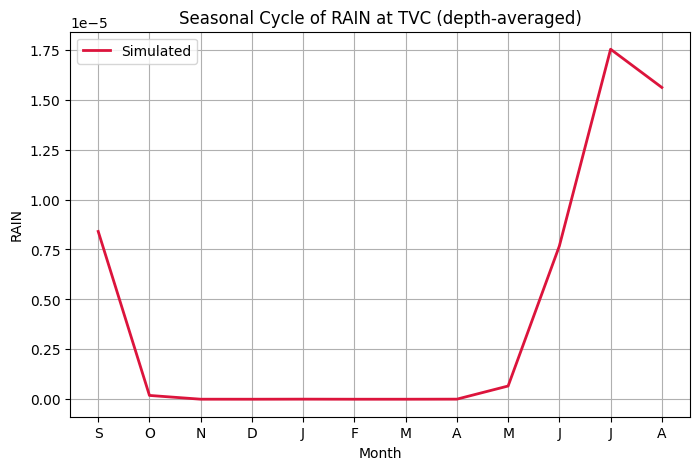

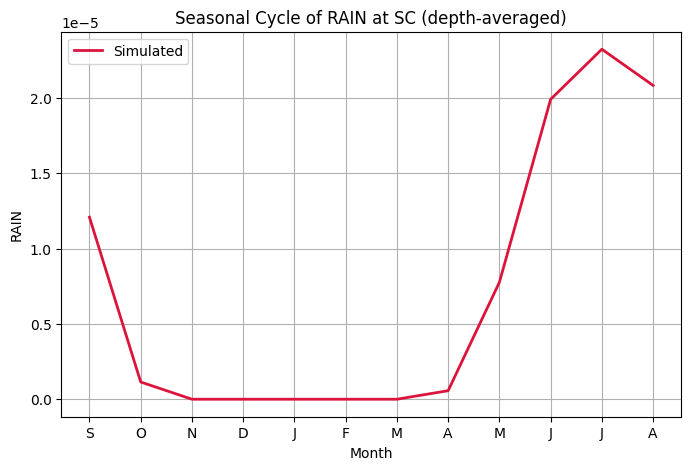

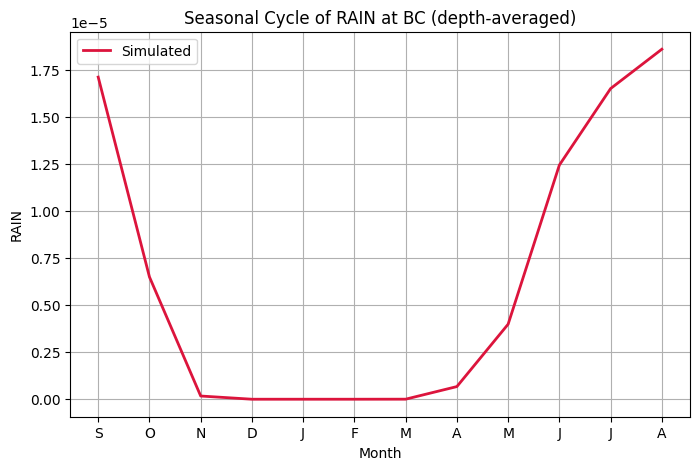

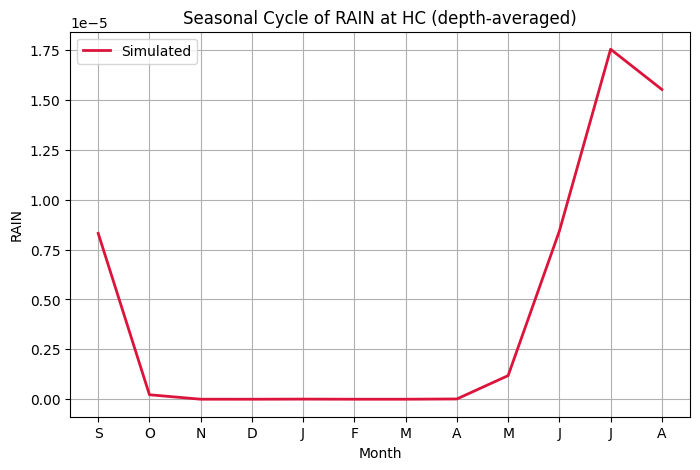

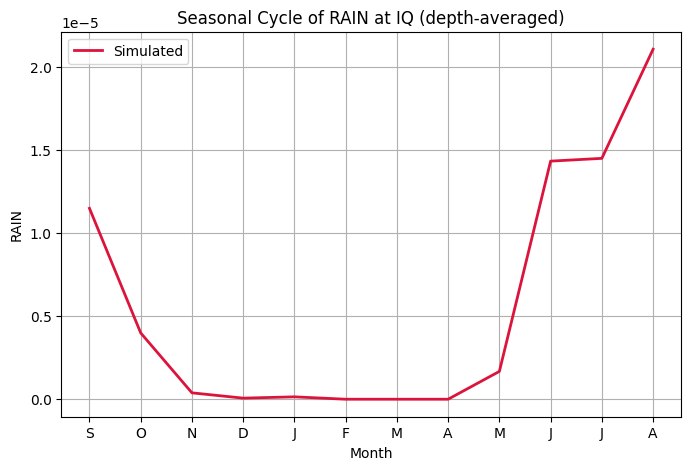

In [ ]:
for site in sites:
    
    # pull ctsm file
    ctsm_file = f"..\\CTSM_data\\run_1\\merged_files\\{site}_1995-2014.nc"
    df = xr.open_dataset(ctsm_file, engine="netcdf4")
    df = df['RAIN']
    seasonal_rain(df, f"{site}", "RAIN", show=1)

        
        



In [6]:
df["RAIN"]

KeyError: 'RAIN'

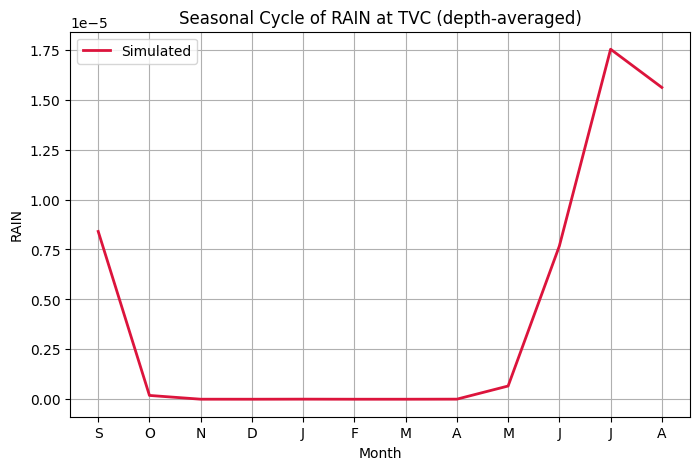